# Coffee Bean Roast Level Classification - Preprocessing and EDA

This notebook loads the coffee bean dataset, preprocesses images (background removal), and performs exploratory data analysis.

## Imports and Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import shutil
import re
import hashlib
import cv2

# Custom functions
from coffee_utils import load_image, remove_background

import warnings
warnings.filterwarnings('ignore')

### Paths

In [2]:
# Base path for data (relative to this notebook, which lives in Code/)
BASE_PATH = Path("coffee_data")
ROAST_LEVELS = ["Green", "Light", "Medium", "Dark"]

### Combine Train and Test Images

Combine images from the original train/test split into unified roast-level folders (Green, Light, Medium, Dark). Training images keep their original names (1-300); test images are renamed by adding 300 to their number (e.g., `light (1).png` -> `light (301).png`).

In [3]:
ORIGINAL_PATH = BASE_PATH / "original_dataset"
ROAST_LEVELS = ["Green", "Light", "Medium", "Dark"]
TRAIN_TEST_OFFSET = 300  # Add this to test image numbers to avoid collisions

for roast in ROAST_LEVELS:
    out_dir = BASE_PATH / roast
    out_dir.mkdir(parents = True, exist_ok = True)

    # Copy train images with unchanged names
    train_dir = ORIGINAL_PATH / "train" / roast
    if train_dir.exists():
        for f in train_dir.iterdir():
            if f.is_file():
                shutil.copy2(f, out_dir / f.name)
        print(f"{roast}: copied {len(list(out_dir.iterdir()))} train images")

    # Copy test images, renaming: roastname (N).ext -> roastname (N+300).ext
    test_dir = ORIGINAL_PATH / "test" / roast
    if test_dir.exists():
        count = 0
        for f in test_dir.iterdir():
            if f.is_file():
                match = re.match(r"^(.+)\s\((\d+)\)(\.[^.]+)$", f.name, re.IGNORECASE)
                if match:
                    prefix, num, ext = match.group(1), int(match.group(2)), match.group(3)
                    new_name = f"{prefix} ({num + TRAIN_TEST_OFFSET}){ext}"
                    shutil.copy2(f, out_dir / new_name)
                    count += 1
                else:
                    shutil.copy2(f, out_dir / f.name)
                    count += 1
        
        print(f"{roast}: added {count} test images (renamed 301-400)")
        print(f"  Total: {len(list(out_dir.iterdir()))} images in {roast}/")

Green: copied 300 train images
Green: added 100 test images (renamed 301-400)
  Total: 400 images in Green/
Light: copied 300 train images
Light: added 100 test images (renamed 301-400)
  Total: 400 images in Light/
Medium: copied 300 train images
Medium: added 100 test images (renamed 301-400)
  Total: 400 images in Medium/
Dark: copied 300 train images
Dark: added 100 test images (renamed 301-400)
  Total: 400 images in Dark/


### Load and Inspect CSV

In [4]:
# Build dataframe from unified roast-level folders (Green/, Light/, Medium/, Dark/)
rows = []
for roast in ROAST_LEVELS:
    folder = BASE_PATH / roast
    if folder.exists():
        for f in sorted(folder.glob("*.png")):
            rows.append({"filepaths": str(folder / f.name), "labels": roast})

df = pd.DataFrame(rows)

print("Image counts per roast level:")
print(df["labels"].value_counts().sort_index())
print("\nFirst few rows:")
df.head(10)

Image counts per roast level:
labels
Dark      400
Green     400
Light     400
Medium    400
Name: count, dtype: int64

First few rows:


,filepaths,labels
0,coffee_data\Green\green (1).png,Green
1,coffee_data\Green\green (10).png,Green
2,coffee_data\Green\green (100).png,Green
3,coffee_data\Green\green (101).png,Green
4,coffee_data\Green\green (102).png,Green
5,coffee_data\Green\green (103).png,Green
6,coffee_data\Green\green (104).png,Green
7,coffee_data\Green\green (105).png,Green
8,coffee_data\Green\green (106).png,Green
9,coffee_data\Green\green (107).png,Green


In [5]:
# Image counts per roast level
print("Counts per label:")
print(df["labels"].value_counts().sort_index())

Counts per label:
labels
Dark      400
Green     400
Light     400
Medium    400
Name: count, dtype: int64


## Identify Duplicate Images

Check for duplicate images within each roast-level folder using file hashing. Duplicates are images with identical file contents/pixels.

In [6]:
def find_duplicates_per_folder(base_path, roast_levels, extensions = (".png", ".jpg", ".jpeg")):
    """Identify duplicate images within each roast folder by file hash (MD5)."""
    results = {}
    for roast in roast_levels:
        folder = base_path / roast
        if not folder.exists():
            continue
        
        hash_to_files = {}
        for f in folder.iterdir():
            if not f.is_file() or f.suffix.lower() not in extensions:
                continue
            with open(f, "rb") as fp:
                h = hashlib.md5(fp.read()).hexdigest()
            hash_to_files.setdefault(h, []).append(f.name)
        
        duplicates = {h: files for h, files in hash_to_files.items() if len(files) > 1}
        results[roast] = duplicates
    
    return results

duplicates_by_roast = find_duplicates_per_folder(BASE_PATH, ROAST_LEVELS)
total_dup_groups = sum(len(v) for v in duplicates_by_roast.values())
total_dup_files = sum(sum(len(files) for files in v.values()) for v in duplicates_by_roast.values())

if total_dup_groups == 0:
    print("No duplicate images found in any roast-level folder.")
else:
    print(f"Found {total_dup_groups} duplicate group(s) across {total_dup_files} file(s):\n")
    for roast in ROAST_LEVELS:
        dup = duplicates_by_roast.get(roast, {})
        if dup:
            print(f"  {roast}/ ({len(dup)} group(s)):")
            for h, files in dup.items():
                print(f"    Hash {h[:12]}...: {files}")

Found 403 duplicate group(s) across 809 file(s):

  Green/ (101 group(s)):
    Hash ad422860c395...: ['green (102).png', 'green (334).png']
    Hash 468165b04c52...: ['green (105).png', 'green (335).png']
    Hash 41a61b70afa9...: ['green (106).png', 'green (336).png']
    Hash 1ab6f8f313ff...: ['green (109).png', 'green (337).png']
    Hash 1c122257531a...: ['green (110).png', 'green (338).png']
    Hash d8d665ce334b...: ['green (117).png', 'green (339).png']
    Hash 1604c8b49fb5...: ['green (118).png', 'green (340).png']
    Hash a115dcf85d78...: ['green (12).png', 'green (303).png']
    Hash a229a1021b6a...: ['green (122).png', 'green (341).png']
    Hash 7c5a1c2cac4c...: ['green (125).png', 'green (342).png']
    Hash 80df6daaaee7...: ['green (126).png', 'green (343).png']
    Hash 02e42cf820cf...: ['green (128).png', 'green (344).png']
    Hash 6d6919b10059...: ['green (130).png', 'green (345).png']
    Hash 46748459df60...: ['green (133).png', 'green (346).png']
    Hash 539b0d9

It appears that in the original dataset, the testing images are simply duplicates of some training images. As well, there are a few actual duplicate images in Green and Dark. I will remove all duplicate images and do a random train/test split later.

In [7]:
# Deduplicate: keep one file per hash per roast level, delete the rest
deleted_count = 0
for roast in ROAST_LEVELS:
    dup = duplicates_by_roast.get(roast, {})
    folder = BASE_PATH / roast
    for h, files in dup.items():
        # Keep first file, delete the rest
        to_keep, to_delete = files[0], files[1:]
        for fname in to_delete:
            path = folder / fname
            if path.exists():
                path.unlink()
                deleted_count += 1

print(f"Deleted {deleted_count} duplicate image(s).")
print("Remaining counts per roast level:")

for roast in ROAST_LEVELS:
    folder = BASE_PATH / roast
    n = len(list(folder.glob("*.png"))) if folder.exists() else 0
    print(f"  {roast}: {n} images")

# Rebuild df from deduplicated folders so subsequent cells use correct paths
rows = []
for roast in ROAST_LEVELS:
    folder = BASE_PATH / roast
    if folder.exists():
        for f in sorted(folder.glob("*.png")):
            rows.append({"filepaths": str(folder / f.name), "labels": roast})

df = pd.DataFrame(rows)
print(f"\nRebuilt df: {len(df)} total images")

Deleted 406 duplicate image(s).
Remaining counts per roast level:
  Green: 299 images
  Light: 300 images
  Medium: 300 images
  Dark: 295 images

Rebuilt df: 1194 total images


## Preprocessing

### Background Removal

We remove the light background from each image using Otsu thresholding and morphology, keeping only the bean. The background is set to black. Below is the before/after for one sample per roast level.

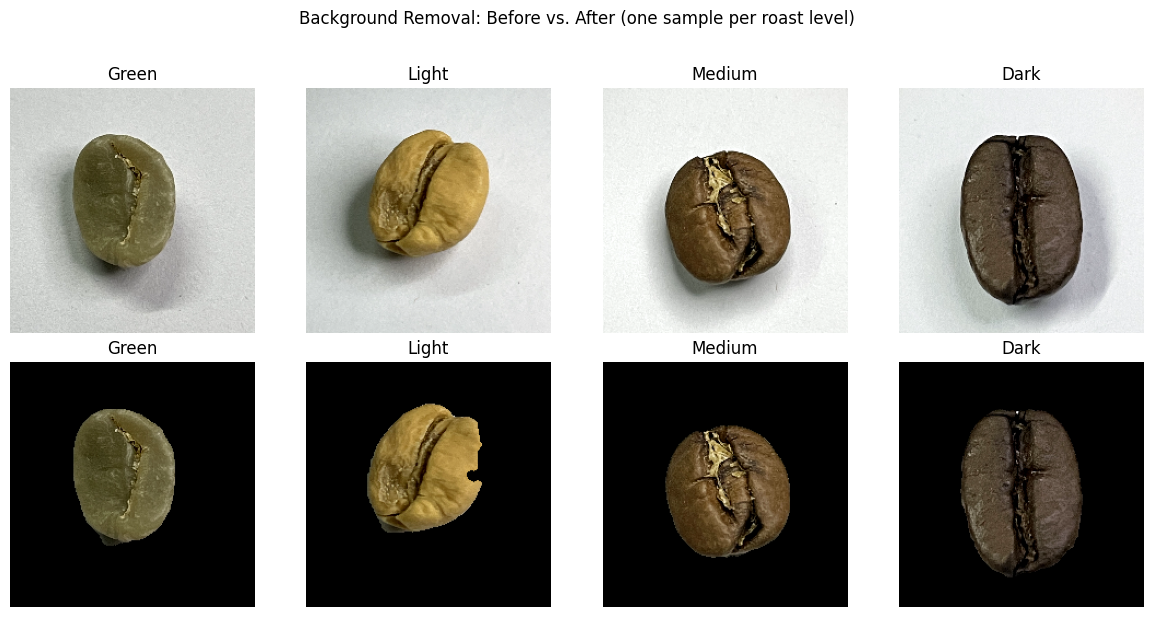

In [8]:
# Pick one sample per roast level from unified folders
labels = ["Green", "Light", "Medium", "Dark"]
samples = []
for label in labels:
    row = df[df["labels"] == label].iloc[0]
    samples.append({"path": row["filepaths"], "label": label})

fig, axes = plt.subplots(2, 4, figsize = (12, 6))
axes[0, 0].set_ylabel("Original", fontsize = 11)
axes[1, 0].set_ylabel("Masked", fontsize = 11)

for j, s in enumerate(samples):
    img_path = Path(s["path"])
    img = load_image(img_path)
    masked = remove_background(img)

    axes[0, j].imshow(img)
    axes[0, j].set_title(s["label"])
    axes[0, j].axis("off")

    axes[1, j].imshow(masked)
    axes[1, j].set_title(s["label"])
    axes[1, j].axis("off")

plt.suptitle("Background Removal: Before vs. After (one sample per roast level)", fontsize = 12, y = 1.02)
plt.tight_layout()
plt.show()

### Save All Processed Images

Process all images and overwrite them in place in the Green, Light, Medium, and Dark folders. Original data is backed up in `original_dataset/`.

In [9]:
# Process all images and overwrite in place (Green/, Light/, Medium/, Dark/)
n_total = len(df)
for idx, (_, row) in enumerate(df.iterrows()):
    src = Path(row["filepaths"])
    img = load_image(src)
    masked = remove_background(img)
    cv2.imwrite(str(src), cv2.cvtColor(masked, cv2.COLOR_RGB2BGR))
    if (idx + 1) % 200 == 0 or idx == n_total - 1:
        print(f"  Processed {idx + 1}/{n_total} images")

print("\nDone. Processed images overwritten in Green/, Light/, Medium/, Dark/.")

  Processed 200/1194 images
  Processed 400/1194 images
  Processed 600/1194 images
  Processed 800/1194 images
  Processed 1000/1194 images
  Processed 1194/1194 images

Done. Processed images overwritten in Green/, Light/, Medium/, Dark/.


## Exploratory Data Analysis

Now, we can analyze the processed images. Each section has summary statistics (tables) first, then visualizations.

### Load Processed Images

In [10]:
# Processed images are in place; filepaths point to them
images_df = df.copy()
images_df["processed_path"] = images_df["filepaths"]
print(f"Total images: {len(images_df)}")
images_df[["labels", "processed_path"]].head()

order = ["Green", "Light", "Medium", "Dark"]  # Roast level order for plots

Total images: 1194


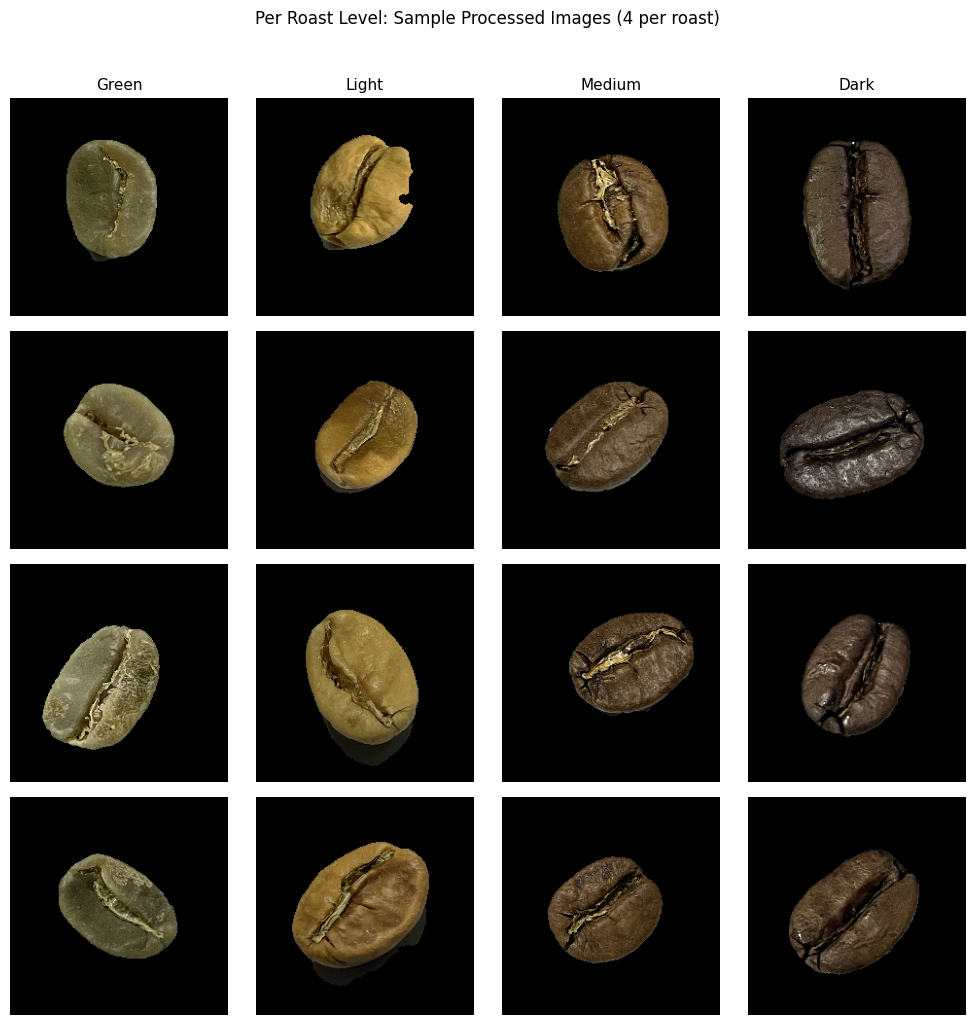

Green: ['green (1).png', 'green (10).png', 'green (100).png', 'green (101).png']
Light: ['light (1).png', 'light (10).png', 'light (100).png', 'light (101).png']
Medium: ['medium (1).png', 'medium (10).png', 'medium (100).png', 'medium (101).png']
Dark: ['dark (1).png', 'dark (10).png', 'dark (100).png', 'dark (101).png']


In [11]:
# Sample images per roast level (4 per roast)
order = ["Green", "Light", "Medium", "Dark"]
fig, axes = plt.subplots(4, 4, figsize = (10, 10))

for j, label in enumerate(order):
    sub = images_df[images_df["labels"] == label].head(4)
    for i, (_, row) in enumerate(sub.iterrows()):
        img = load_image(row["processed_path"])
        axes[i, j].imshow(img)
        axes[i, j].axis("off")
        if i == 0:
            axes[i, j].set_title(label, fontsize = 11)

plt.suptitle("Per Roast Level: Sample Processed Images (4 per roast)", fontsize = 12, y = 1.02)
plt.tight_layout()
plt.show()

# Tabular equivalent: sample image paths per roast
for lbl in order:
    paths = images_df[images_df["labels"] == lbl]["processed_path"].head(4).tolist()
    print(f"{lbl}: {[Path(p).name for p in paths]}")

## RGB Features

### Summary Statistics - Overall

Mean R, G, B per image (bean pixels only).

In [12]:
def compute_bean_color_stats(img, bg_threshold = 5):
    """Compute mean and std of R, G, B over bean pixels only (exclude black background)."""
    # Bean pixels = exclude black background (same convention as coffee_utils.extract_features)
    mask = (img.sum(axis = 2) > bg_threshold)
    if not mask.any():
        return np.nan, np.nan, np.nan, np.nan, np.nan, np.nan
    r_ch = img[:, :, 0][mask]
    g_ch = img[:, :, 1][mask]
    b_ch = img[:, :, 2][mask]
    return r_ch.mean(), g_ch.mean(), b_ch.mean(), r_ch.std(), g_ch.std(), b_ch.std()

# Compute per-image color stats (may take 1-2 minutes for 1600 images)
stats = []
for _, row in images_df.iterrows():
    img = load_image(row["processed_path"])
    r, g, b, std_r, std_g, std_b = compute_bean_color_stats(img)
    stats.append({"mean_R": r, "mean_G": g, "mean_B": b, "std_R": std_r, "std_G": std_g, "std_B": std_b, "labels": row["labels"]})

stats_df = pd.DataFrame(stats)
print("Overall summary (mean R, G, B across all images):")
stats_df[["mean_R", "mean_G", "mean_B"]].describe().round(2)

Overall summary (mean R, G, B across all images):


,mean_R,mean_G,mean_B
count,1194.00,1194.00,1194.00
mean,100.64,82.89,50.78
std,28.95,26.23,17.71
min,36.52,28.48,14.15
25%,75.45,61.14,38.57
50%,102.31,80.42,46.95
75%,125.89,105.58,60.37
max,166.36,145.18,114.61


### Summary Statistics - Per Roast Level

In [13]:
print("Mean R, G, B per roast level (mean of per-image means):\n")
stats_by_roast = stats_df.groupby("labels")[["mean_R", "mean_G", "mean_B"]].agg(["mean", "std", "count"])
print(stats_by_roast.round(2).to_string())

# Add mean luminance (0.299*R + 0.587*G + 0.114*B) for reference
stats_df["mean_luminance"] = 0.299 * stats_df["mean_R"] + 0.587 * stats_df["mean_G"] + 0.114 * stats_df["mean_B"]
print("\nMean luminance per roast level:")
stats_df.groupby("labels")["mean_luminance"].agg(["mean", "std"]).round(2)

Mean R, G, B per roast level (mean of per-image means):

        mean_R               mean_G              mean_B             
          mean    std count    mean    std count   mean    std count
labels                                                              
Dark     67.23  11.65   295   55.80  10.71   295  44.43   9.84   295
Green   122.41  13.35   299  112.48  12.39   299  74.85  12.80   299
Light   126.93  15.98   300   97.06  13.94   300  43.97   9.77   300
Medium   85.50  16.67   300   65.85  13.84   300  39.86  10.61   300

Mean luminance per roast level:


,mean,std
labels,,
Dark,57.92,10.78
Green,111.16,12.60
Light,99.94,13.61
Medium,68.76,14.23


### Visualizations

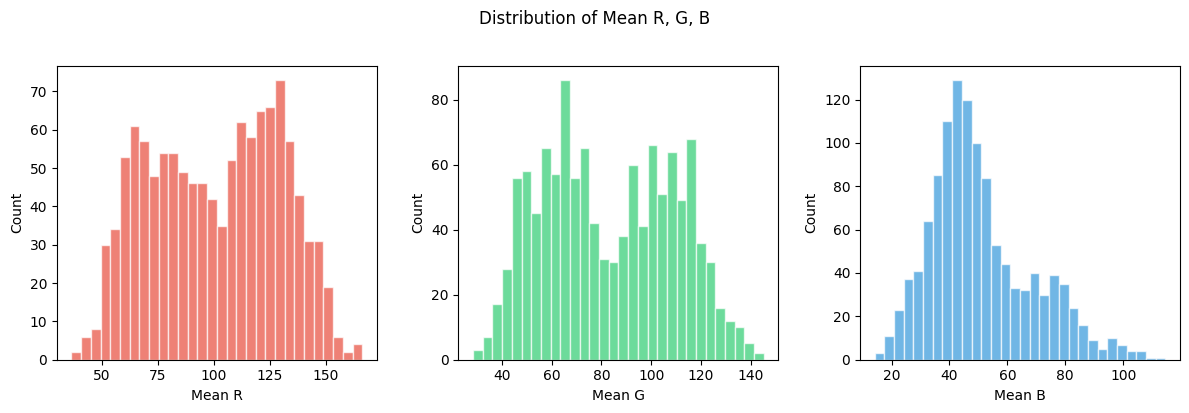

        mean_R   mean_G   mean_B
count  1194.00  1194.00  1194.00
mean    100.64    82.89    50.78
std      28.95    26.23    17.71
min      36.52    28.48    14.15
25%      75.45    61.14    38.57
50%     102.31    80.42    46.95
75%     125.89   105.58    60.37
max     166.36   145.18   114.61


In [14]:
# Histograms: mean R, G, B
fig, axes = plt.subplots(1, 3, figsize = (12, 4))
colors = ["#e74c3c", "#2ecc71", "#3498db"]
for ax, col, c in zip(axes, ["mean_R", "mean_G", "mean_B"], colors):
    ax.hist(stats_df[col], bins = 30, color = c, alpha = 0.7, edgecolor = "white")
    ax.set_xlabel(col.replace("mean_", "Mean "))
    ax.set_ylabel("Count")

plt.suptitle("Distribution of Mean R, G, B", fontsize = 12, y = 1.02)
plt.tight_layout()
plt.show()

# Tabular: percentiles
print(stats_df[["mean_R", "mean_G", "mean_B"]].describe().round(2))

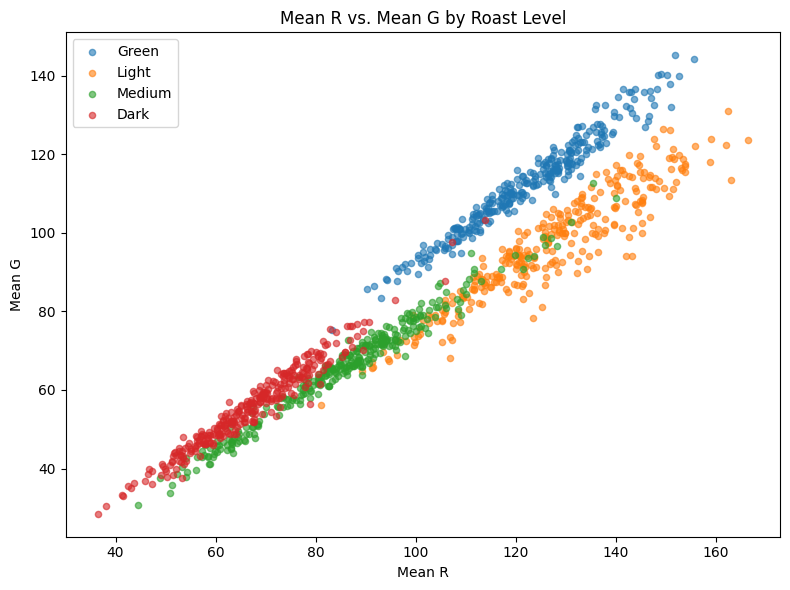

        mean_R  mean_G
labels                
Green   122.41  112.48
Light   126.93   97.06
Medium   85.50   65.85
Dark     67.23   55.80


In [15]:
# Scatter: mean R vs. mean G by roast
plt.figure(figsize = (8, 6))
for label in order:
    sub = stats_df[stats_df["labels"] == label]
    plt.scatter(sub["mean_R"], sub["mean_G"], label = label, alpha = 0.6, s = 20)
plt.xlabel("Mean R"); plt.ylabel("Mean G")
plt.title("Mean R vs. Mean G by Roast Level"); plt.legend()
plt.tight_layout(); plt.show()

# Tabular: mean R, G by roast
print(stats_df.groupby("labels")[["mean_R", "mean_G"]].mean().reindex(order).round(2))

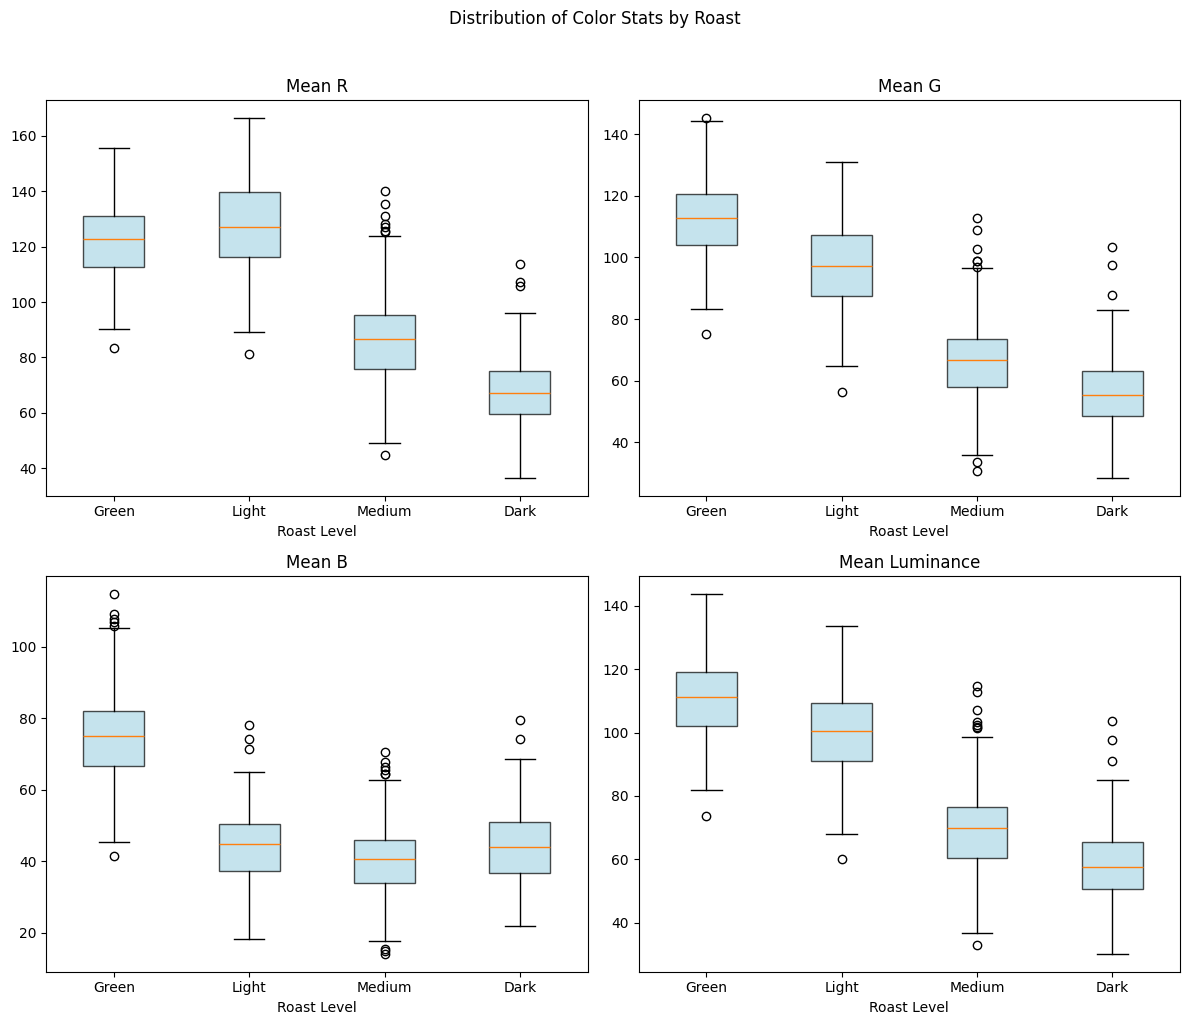

        mean_R         mean_G        mean_B        mean_luminance       
          mean    std    mean    std   mean    std           mean    std
labels                                                                  
Dark     67.23  11.65   55.80  10.71  44.43   9.84          57.92  10.78
Green   122.41  13.35  112.48  12.39  74.85  12.80         111.16  12.60
Light   126.93  15.98   97.06  13.94  43.97   9.77          99.94  13.61
Medium   85.50  16.67   65.85  13.84  39.86  10.61          68.76  14.23


In [16]:
# Box plots: mean R, G, B, luminance per roast
fig, axes = plt.subplots(2, 2, figsize = (12, 10))
vars_ = ["mean_R", "mean_G", "mean_B", "mean_luminance"]
titles = ["Mean R", "Mean G", "Mean B", "Mean Luminance"]

for ax, var, title in zip(axes.flat, vars_, titles):
    data = [stats_df[stats_df["labels"] == lbl][var].dropna().values for lbl in order]
    bp = ax.boxplot(data, labels = order, patch_artist = True)
    for p in bp["boxes"]: p.set_facecolor("lightblue"); p.set_alpha(0.7)
    ax.set_title(title); ax.set_xlabel("Roast Level")
plt.suptitle("Distribution of Color Stats by Roast", fontsize = 12, y = 1.02)
plt.tight_layout(); plt.show()

# Tabular: mean and std per roast
print(stats_df.groupby("labels")[vars_].agg(["mean","std"]).round(2))

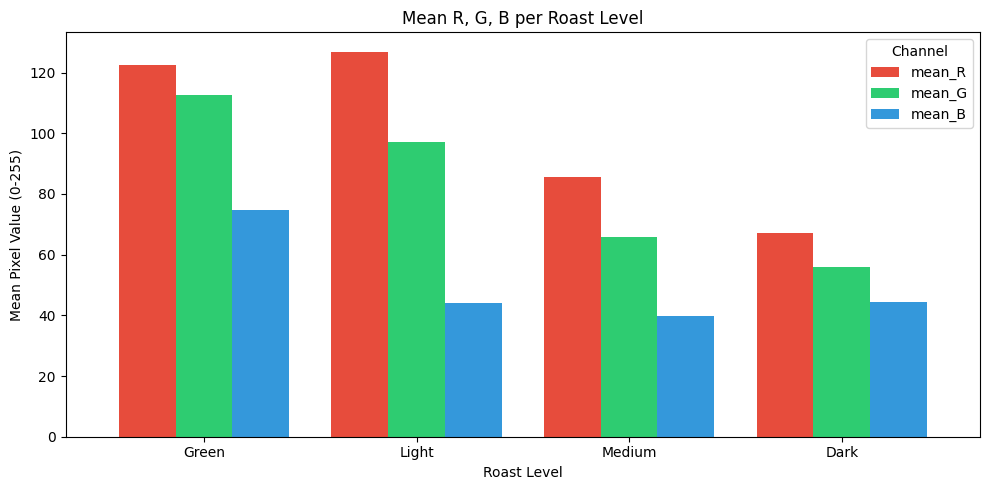

        mean_R  mean_G  mean_B
labels                        
Green   122.41  112.48   74.85
Light   126.93   97.06   43.97
Medium   85.50   65.85   39.86
Dark     67.23   55.80   44.43


In [17]:
# Bar chart: mean R, G, B per roast
roast_means = stats_df.groupby("labels")[["mean_R", "mean_G", "mean_B"]].mean().reindex(order)
roast_means.plot(kind = "bar", figsize = (10, 5), color = ["#e74c3c", "#2ecc71", "#3498db"], width = 0.8)
plt.xlabel("Roast Level"); plt.ylabel("Mean Pixel Value (0-255)")
plt.title("Mean R, G, B per Roast Level"); plt.legend(title = "Channel")
plt.xticks(rotation = 0); plt.tight_layout(); plt.show()

# Tabular
print(roast_means.round(2))

## HSV Features

### Compute and Summary Statistics

In [18]:
# Add color ratios from existing RGB (add small epsilon to avoid division by zero)
eps = 1e-6
stats_df["ratio_RG"] = stats_df["mean_R"] / (stats_df["mean_G"] + eps)
stats_df["ratio_BG"] = stats_df["mean_B"] / (stats_df["mean_G"] + eps)

# Compute HSV and texture (gray-level std) per image
def compute_bean_hsv_texture(img, bg_threshold = 5):
    """Compute mean and std of H, S, V and gray_std over bean pixels only (exclude black background)."""
    # Bean pixels = exclude black background (same convention as coffee_utils.extract_features)
    mask = (img.sum(axis = 2) > bg_threshold)
    if not mask.any():
        return np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan
    hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
    h, s, v = hsv[:, :, 0][mask], hsv[:, :, 1][mask], hsv[:, :, 2][mask]
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    
    return h.mean(), s.mean(), v.mean(), h.std(), s.std(), v.std(), gray[mask].std()

hsv_texture = []
for _, row in images_df.iterrows():
    img = load_image(row["processed_path"])
    h, s, v, std_h, std_s, std_v, gray_std = compute_bean_hsv_texture(img)
    hsv_texture.append({"mean_H": h, "mean_S": s, "mean_V": v, "std_H": std_h, "std_S": std_s, "std_V": std_v, "gray_std": gray_std})

hsv_df = pd.DataFrame(hsv_texture)
stats_df["mean_H"] = hsv_df["mean_H"]
stats_df["mean_S"] = hsv_df["mean_S"]
stats_df["mean_V"] = hsv_df["mean_V"]
stats_df["std_H"] = hsv_df["std_H"]
stats_df["std_S"] = hsv_df["std_S"]
stats_df["std_V"] = hsv_df["std_V"]
stats_df["gray_std"] = hsv_df["gray_std"]

print("Added: mean_H, mean_S, mean_V, std_H, std_S, std_V (HSV), ratio_RG, ratio_BG, gray_std")

Added: mean_H, mean_S, mean_V, std_H, std_S, std_V (HSV), ratio_RG, ratio_BG, gray_std


In [19]:
print("Overall summary (HSV, ratios, texture):")
stats_df[["mean_H", "mean_S", "mean_V", "ratio_RG", "ratio_BG", "gray_std"]].describe().round(2)

Overall summary (HSV, ratios, texture):


,mean_H,mean_S,mean_V,ratio_RG,ratio_BG,gray_std
count,1194.00,1194.00,1194.00,1194.00,1194.00,1194.00
mean,19.48,133.03,100.68,1.23,0.63,31.71
std,4.23,32.25,28.96,0.10,0.14,5.58
min,13.26,62.17,37.08,1.03,0.26,15.82
25%,16.42,106.39,75.45,1.13,0.52,27.80
50%,18.12,131.71,102.31,1.24,0.63,31.42
75%,22.47,157.39,125.93,1.31,0.72,35.28
max,41.69,212.90,166.36,1.58,0.91,53.54


### Visualizations

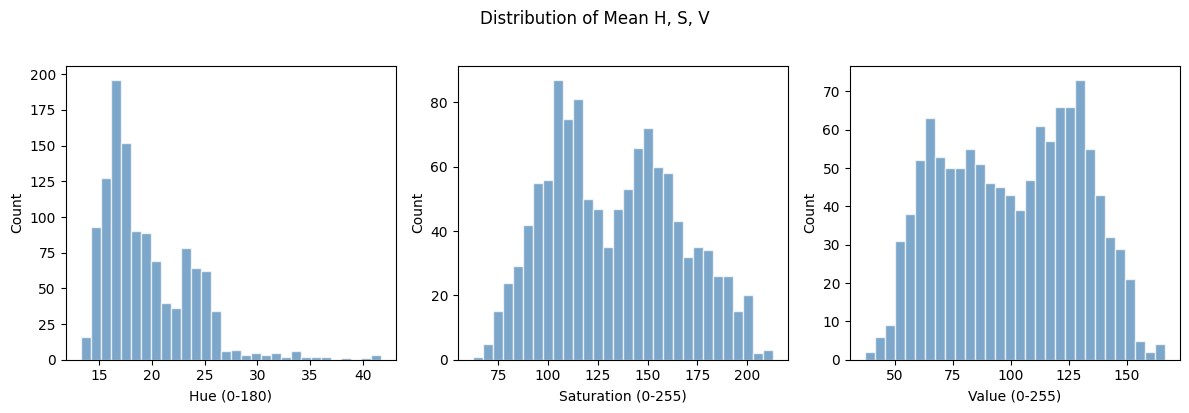

        mean_H   mean_S   mean_V
count  1194.00  1194.00  1194.00
mean     19.48   133.03   100.68
std       4.23    32.25    28.96
min      13.26    62.17    37.08
25%      16.42   106.39    75.45
50%      18.12   131.71   102.31
75%      22.47   157.39   125.93
max      41.69   212.90   166.36


In [20]:
# Histograms: mean H, S, V
fig, axes = plt.subplots(1, 3, figsize = (12, 4))
for ax, col, title in zip(axes, ["mean_H", "mean_S", "mean_V"], ["Hue (0-180)", "Saturation (0-255)", "Value (0-255)"]):
    ax.hist(stats_df[col].dropna(), bins = 30, color = "steelblue", alpha = 0.7, edgecolor = "white")
    ax.set_xlabel(title); ax.set_ylabel("Count")
plt.suptitle("Distribution of Mean H, S, V", fontsize = 12, y = 1.02)
plt.tight_layout(); plt.show()

# Tabular
print(stats_df[["mean_H", "mean_S", "mean_V"]].describe().round(2))

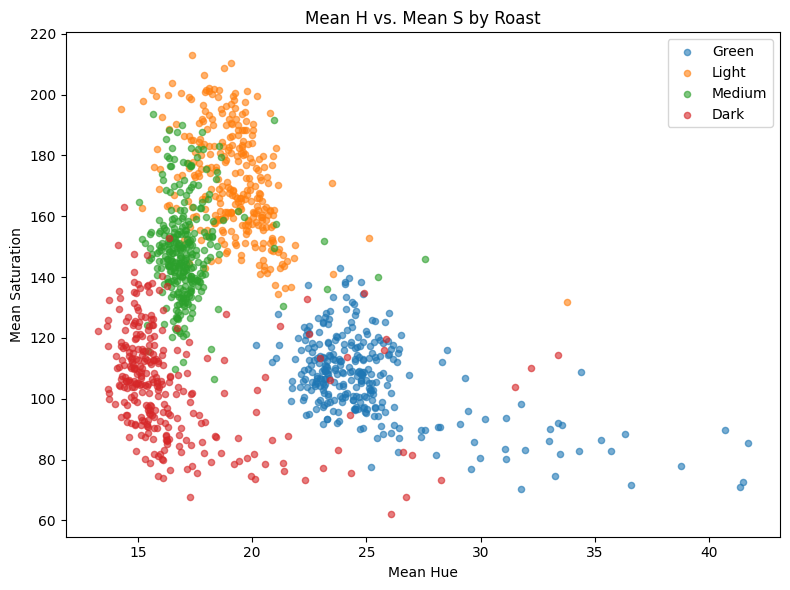

        mean_H  mean_S
labels                
Green    25.12  106.81
Light    19.16  170.97
Medium   17.10  148.48
Dark     16.51  105.33


In [21]:
# Scatter: Hue vs. Saturation by roast
plt.figure(figsize = (8, 6))
for label in order:
    sub = stats_df[stats_df["labels"] == label]
    plt.scatter(sub["mean_H"], sub["mean_S"], label = label, alpha = 0.6, s = 20)
plt.xlabel("Mean Hue"); plt.ylabel("Mean Saturation")
plt.title("Mean H vs. Mean S by Roast"); plt.legend()
plt.tight_layout(); plt.show()

# Tabular
print(stats_df.groupby("labels")[["mean_H", "mean_S"]].mean().reindex(order).round(2))

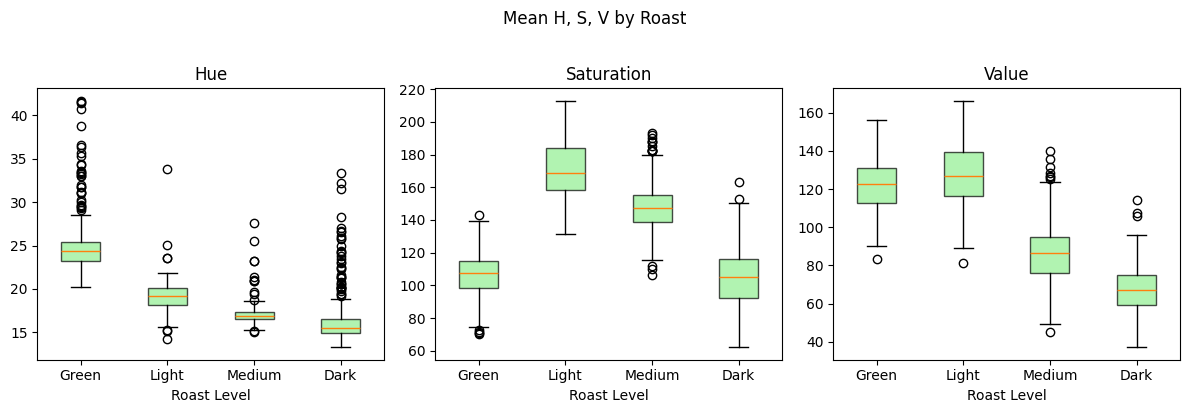

       mean_H        mean_S         mean_V       
         mean   std    mean    std    mean    std
labels                                           
Dark    16.51  3.09  105.33  17.60   67.28  11.62
Green   25.12  3.40  106.81  13.36  122.50  13.46
Light   19.16  1.68  170.97  17.23  126.94  16.00
Medium  17.10  1.26  148.48  15.56   85.51  16.67


In [22]:
# Box plots: mean H, S, V per roast
fig, axes = plt.subplots(1, 3, figsize = (12, 4))
for ax, var, title in zip(axes, ["mean_H", "mean_S", "mean_V"], ["Hue", "Saturation", "Value"]):
    data = [stats_df[stats_df["labels"] == lbl][var].dropna().values for lbl in order]
    bp = ax.boxplot(data, labels = order, patch_artist = True)
    for p in bp["boxes"]: p.set_facecolor("lightgreen"); p.set_alpha(0.7)
    ax.set_title(title); ax.set_xlabel("Roast Level")
plt.suptitle("Mean H, S, V by Roast", fontsize = 12, y = 1.02)
plt.tight_layout(); plt.show()

# Tabular
print(stats_df.groupby("labels")[["mean_H", "mean_S", "mean_V"]].agg(["mean","std"]).round(2))

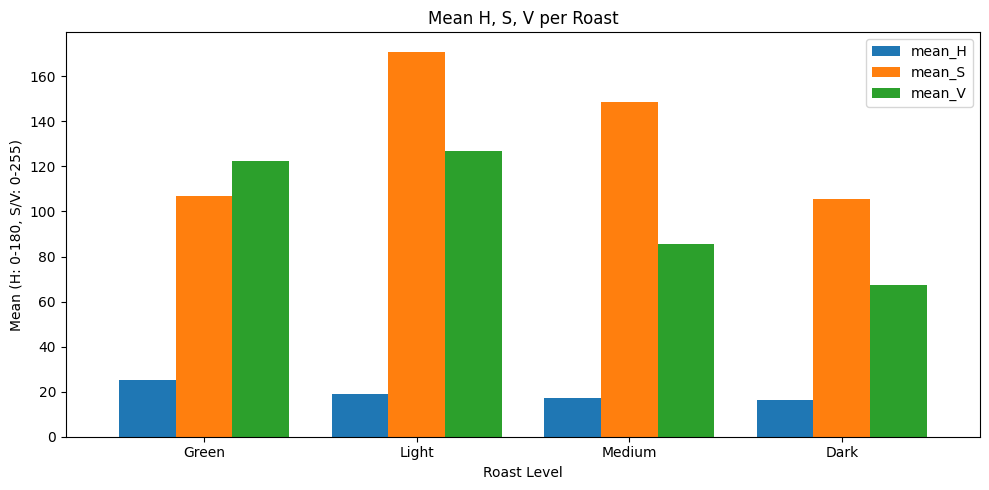

        mean_H  mean_S  mean_V
labels                        
Green    25.12  106.81  122.50
Light    19.16  170.97  126.94
Medium   17.10  148.48   85.51
Dark     16.51  105.33   67.28


In [23]:
# Bar chart: mean H, S, V per roast
roast_hsv = stats_df.groupby("labels")[["mean_H", "mean_S", "mean_V"]].mean().reindex(order)
roast_hsv.plot(kind = "bar", figsize = (10, 5), width = 0.8)
plt.xlabel("Roast Level"); plt.ylabel("Mean (H: 0-180, S/V: 0-255)")
plt.title("Mean H, S, V per Roast"); plt.legend(); plt.xticks(rotation = 0)
plt.tight_layout(); plt.show()

# Tabular
print(roast_hsv.round(2))

## Additional Features (Ratios and Texture)

### Summary Statistics - Per Roast Level

In [24]:
print("Per roast level (mean +/- std) for ratios and texture:")
feat_cols = ["ratio_RG", "ratio_BG", "gray_std"]
stats_df.groupby("labels")[feat_cols].agg(["mean", "std"]).round(2)

Per roast level (mean +/- std) for ratios and texture:


ratio_RG       ratio_BG       gray_std      
           mean   std     mean   std     mean   std
labels                                             
Dark       1.21  0.05     0.79  0.05    32.34  7.25
Green      1.09  0.02     0.66  0.05    30.90  4.49
Light      1.31  0.07     0.45  0.06    33.05  4.74
Medium     1.30  0.05     0.60  0.06    30.58  5.10

### Visualizations

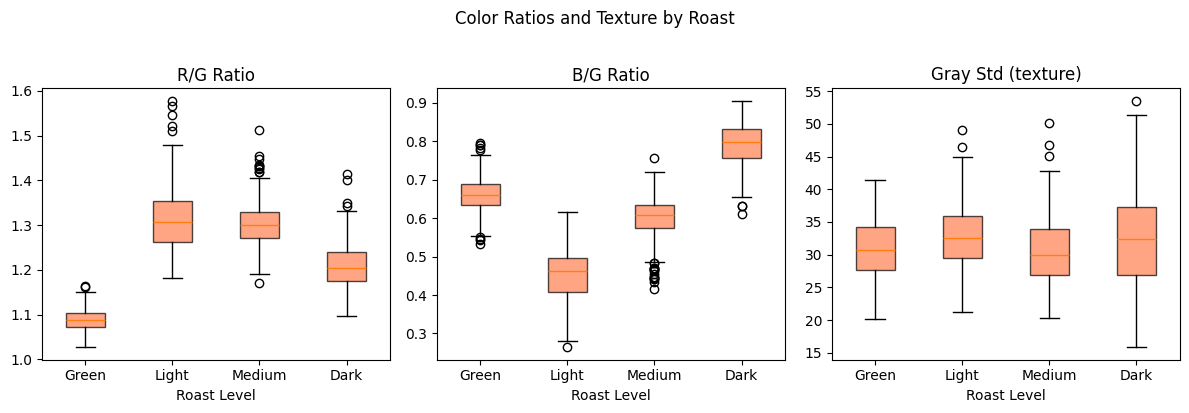

       ratio_RG       ratio_BG       gray_std      
           mean   std     mean   std     mean   std
labels                                             
Dark       1.21  0.05     0.79  0.05    32.34  7.25
Green      1.09  0.02     0.66  0.05    30.90  4.49
Light      1.31  0.07     0.45  0.06    33.05  4.74
Medium     1.30  0.05     0.60  0.06    30.58  5.10


In [25]:
# Box plots: ratio_RG, ratio_BG, gray_std per roast
fig, axes = plt.subplots(1, 3, figsize = (12, 4))
for ax, var, title in zip(axes, ["ratio_RG", "ratio_BG", "gray_std"], ["R/G Ratio", "B/G Ratio", "Gray Std (texture)"]):
    data = [stats_df[stats_df["labels"] == lbl][var].dropna().values for lbl in order]
    bp = ax.boxplot(data, labels = order, patch_artist = True)
    for p in bp["boxes"]: p.set_facecolor("coral"); p.set_alpha(0.7)
    ax.set_title(title); ax.set_xlabel("Roast Level")
plt.suptitle("Color Ratios and Texture by Roast", fontsize = 12, y = 1.02)
plt.tight_layout(); plt.show()

# Tabular
print(stats_df.groupby("labels")[["ratio_RG", "ratio_BG", "gray_std"]].agg(["mean","std"]).round(2))

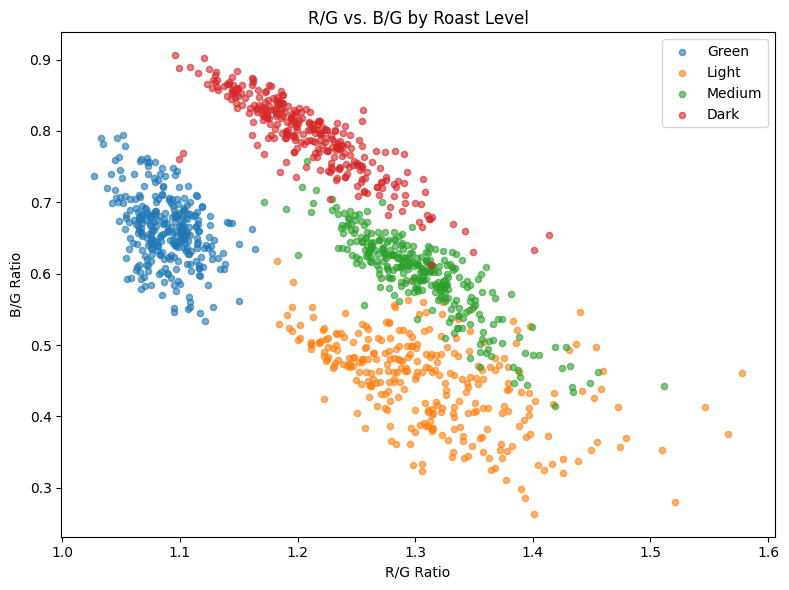

        ratio_RG  ratio_BG
labels                    
Green       1.09      0.66
Light       1.31      0.45
Medium      1.30      0.60
Dark        1.21      0.79


In [26]:
# Scatter: R/G vs. B/G by roast
plt.figure(figsize = (8, 6))
for label in order:
    sub = stats_df[stats_df["labels"] == label]
    plt.scatter(sub["ratio_RG"], sub["ratio_BG"], label = label, alpha = 0.6, s = 20)
plt.xlabel("R/G Ratio"); plt.ylabel("B/G Ratio")
plt.title("R/G vs. B/G by Roast Level"); plt.legend()
plt.tight_layout(); plt.show()

# Tabular
print(stats_df.groupby("labels")[["ratio_RG", "ratio_BG"]].mean().reindex(order).round(2))

## Standard Deviation per Channel

Per-image standard deviation of R, G, B and H, S, V (bean pixels only). Measures color variation across the bean surface.

In [27]:
std_cols = ["std_R", "std_G", "std_B", "std_H", "std_S", "std_V"]
print("Overall summary (std per channel):")
print(stats_df[std_cols].describe().round(2))
print("\nPer roast level (mean of per-image std):")

# Tabular
stats_df.groupby("labels")[std_cols].mean().reindex(order).round(2)

Overall summary (std per channel):
         std_R    std_G    std_B    std_H    std_S    std_V
count  1194.00  1194.00  1194.00  1194.00  1194.00  1194.00
mean     33.26    32.04    28.31     6.38    42.90    33.27
std       6.12     5.67     6.18     7.45     9.01     6.11
min      16.92    15.63    14.73     1.12    19.51    16.91
25%      28.93    28.14    23.65     2.19    37.22    28.96
50%      32.83    31.71    27.34     3.03    41.82    32.84
75%      37.32    35.68    32.08     6.88    46.96    37.33
max      60.42    54.09    53.20    42.42    83.24    60.42

Per roast level (mean of per-image std):


,std_R,std_G,std_B,std_H,std_S,std_V
labels,,,,,,
Green,31.12,31.16,30.38,5.57,36.13,31.21
Light,36.92,33.46,26.09,2.99,40.46,36.92
Medium,32.23,30.96,26.16,4.84,45.41,32.22
Dark,32.76,32.60,30.66,12.21,49.66,32.73


### Visualizations

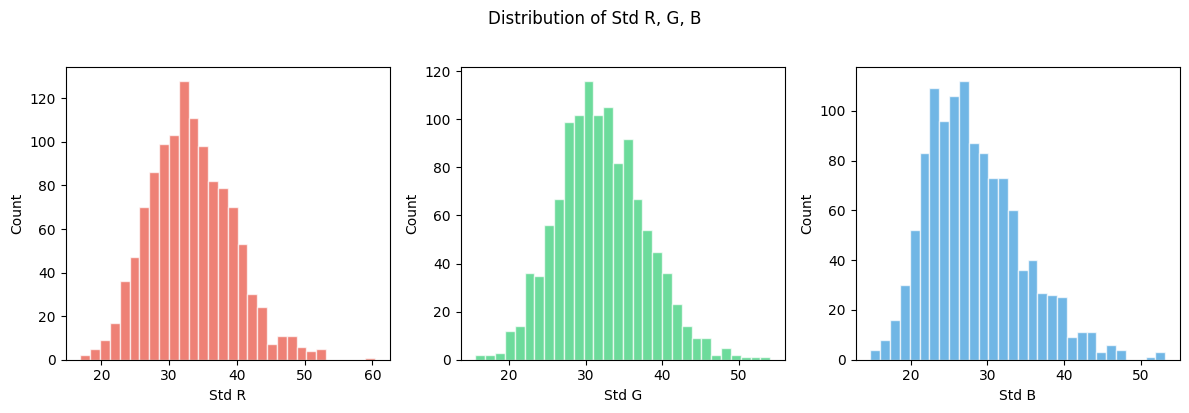

         std_R    std_G    std_B
count  1194.00  1194.00  1194.00
mean     33.26    32.04    28.31
std       6.12     5.67     6.18
min      16.92    15.63    14.73
25%      28.93    28.14    23.65
50%      32.83    31.71    27.34
75%      37.32    35.68    32.08
max      60.42    54.09    53.20


In [28]:
# Histograms: std R, G, B
fig, axes = plt.subplots(1, 3, figsize = (12, 4))
colors = ["#e74c3c", "#2ecc71", "#3498db"]
for ax, col, c in zip(axes, ["std_R", "std_G", "std_B"], colors):
    ax.hist(stats_df[col].dropna(), bins = 30, color = c, alpha = 0.7, edgecolor = "white")
    ax.set_xlabel(col.replace("std_", "Std "))
    ax.set_ylabel("Count")
plt.suptitle("Distribution of Std R, G, B", fontsize = 12, y = 1.02)
plt.tight_layout()
plt.show()

# Tabular
print(stats_df[["std_R", "std_G", "std_B"]].describe().round(2))

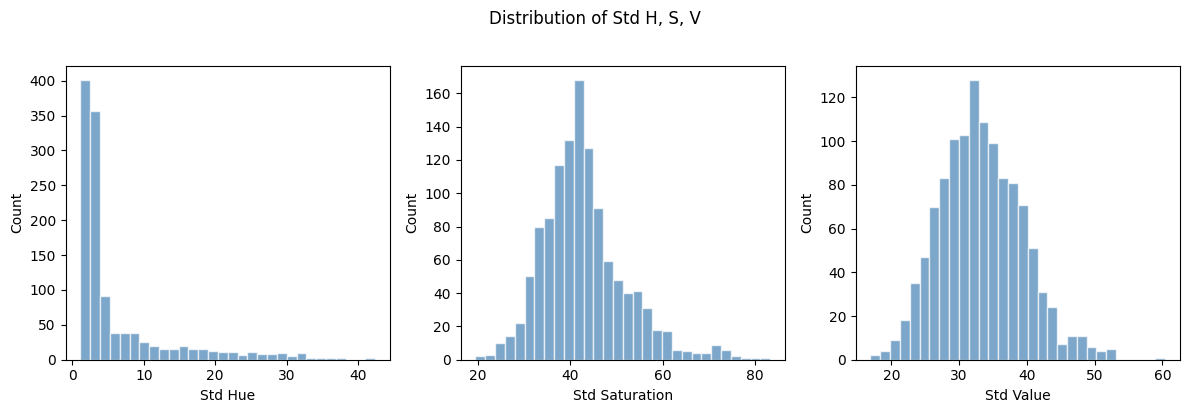

         std_H    std_S    std_V
count  1194.00  1194.00  1194.00
mean      6.38    42.90    33.27
std       7.45     9.01     6.11
min       1.12    19.51    16.91
25%       2.19    37.22    28.96
50%       3.03    41.82    32.84
75%       6.88    46.96    37.33
max      42.42    83.24    60.42


In [29]:
# Histograms: std H, S, V
fig, axes = plt.subplots(1, 3, figsize = (12, 4))
for ax, col, title in zip(axes, ["std_H", "std_S", "std_V"], ["Std Hue", "Std Saturation", "Std Value"]):
    ax.hist(stats_df[col].dropna(), bins = 30, color = "steelblue", alpha = 0.7, edgecolor = "white")
    ax.set_xlabel(title)
    ax.set_ylabel("Count")
plt.suptitle("Distribution of Std H, S, V", fontsize = 12, y = 1.02)
plt.tight_layout()
plt.show()

# Tabular
print(stats_df[["std_H", "std_S", "std_V"]].describe().round(2))

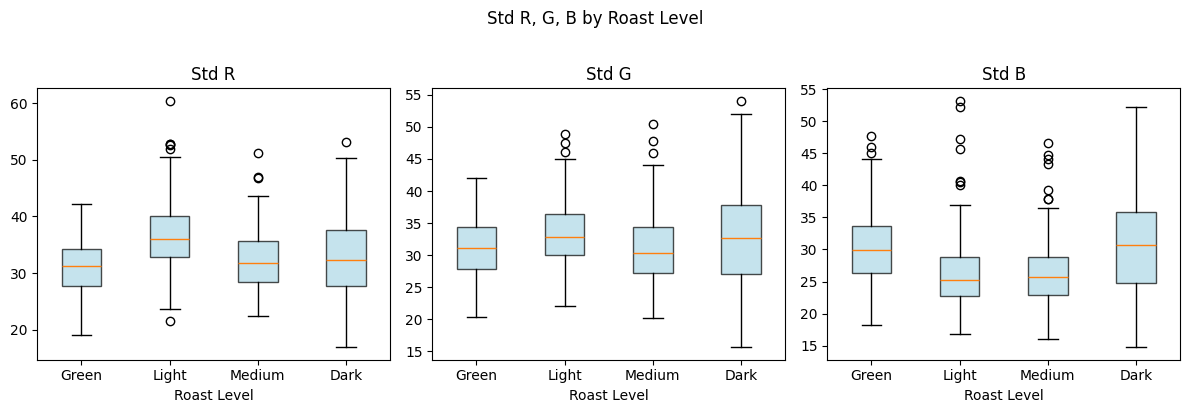

        std_R        std_G        std_B      
         mean   std   mean   std   mean   std
labels                                       
Dark    32.76  6.97  32.60  7.39  30.66  7.42
Green   31.12  4.59  31.16  4.51  30.38  5.50
Light   36.92  5.90  33.46  4.79  26.09  5.04
Medium  32.23  5.16  30.96  5.21  26.16  4.82


In [30]:
# Box plots: std R, G, B per roast level
fig, axes = plt.subplots(1, 3, figsize = (12, 4))
for ax, var, title in zip(axes, ["std_R", "std_G", "std_B"], ["Std R", "Std G", "Std B"]):
    data = [stats_df[stats_df["labels"] == lbl][var].dropna().values for lbl in order]
    bp = ax.boxplot(data, labels = order, patch_artist = True)
    for p in bp["boxes"]: p.set_facecolor("lightblue"); p.set_alpha(0.7)
    ax.set_title(title); ax.set_xlabel("Roast Level")
plt.suptitle("Std R, G, B by Roast Level", fontsize = 12, y = 1.02)
plt.tight_layout()
plt.show()

# Tabular
print(stats_df.groupby("labels")[["std_R", "std_G", "std_B"]].agg(["mean", "std"]).round(2))

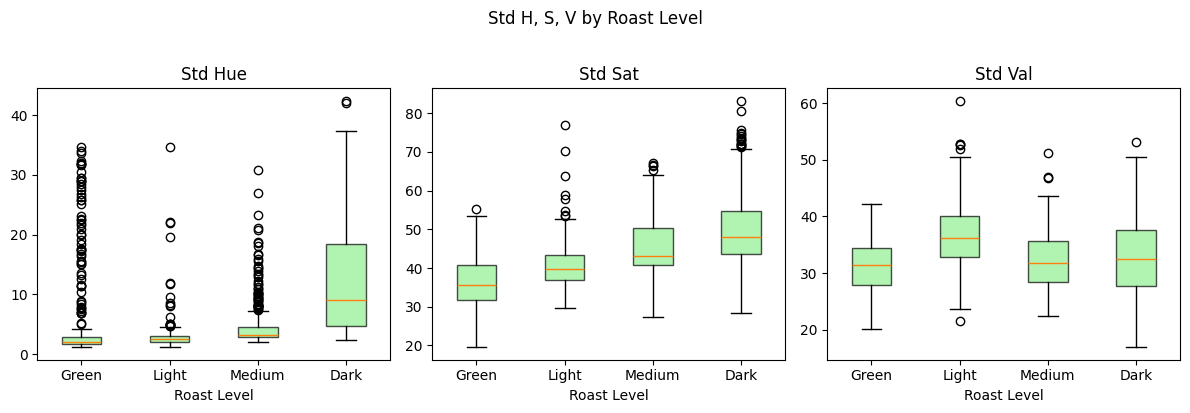

        std_H        std_S        std_V      
         mean   std   mean   std   mean   std
labels                                       
Dark    12.21  9.06  49.66  9.75  32.73  6.96
Green    5.57  8.19  36.13  6.32  31.21  4.57
Light    2.99  2.92  40.46  5.89  36.92  5.89
Medium   4.84  4.18  45.41  7.27  32.22  5.17


In [31]:
# Box plots: std H, S, V per roast level
fig, axes = plt.subplots(1, 3, figsize = (12, 4))
for ax, var, title in zip(axes, ["std_H", "std_S", "std_V"], ["Std Hue", "Std Sat", "Std Val"]):
    data = [stats_df[stats_df["labels"] == lbl][var].dropna().values for lbl in order]
    bp = ax.boxplot(data, labels = order, patch_artist = True)
    for p in bp["boxes"]: p.set_facecolor("lightgreen"); p.set_alpha(0.7)
    ax.set_title(title); ax.set_xlabel("Roast Level")
plt.suptitle("Std H, S, V by Roast Level", fontsize = 12, y = 1.02)
plt.tight_layout()
plt.show()

# Tabular
print(stats_df.groupby("labels")[["std_H", "std_S", "std_V"]].agg(["mean", "std"]).round(2))

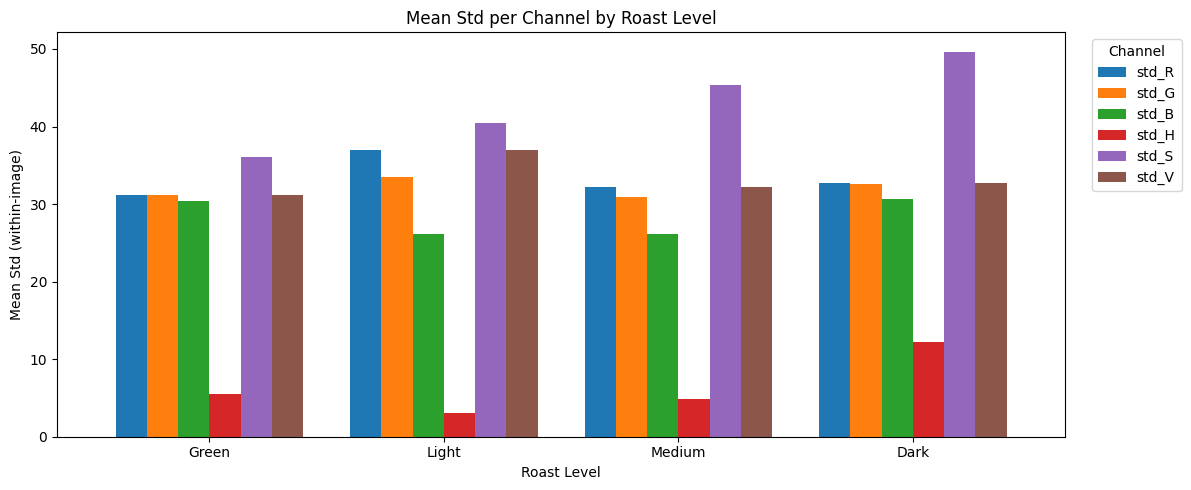

        std_R  std_G  std_B  std_H  std_S  std_V
labels                                          
Green   31.12  31.16  30.38   5.57  36.13  31.21
Light   36.92  33.46  26.09   2.99  40.46  36.92
Medium  32.23  30.96  26.16   4.84  45.41  32.22
Dark    32.76  32.60  30.66  12.21  49.66  32.73


In [32]:
# Bar chart: mean std per channel, per roast level
roast_std = stats_df.groupby("labels")[std_cols].mean().reindex(order)
roast_std.plot(kind = "bar", figsize = (12, 5), width = 0.8)
plt.xlabel("Roast Level")
plt.ylabel("Mean Std (within-image)")
plt.title("Mean Std per Channel by Roast Level")
plt.legend(title = "Channel", bbox_to_anchor = (1.02, 1), loc = "upper left")
plt.xticks(rotation = 0)
plt.tight_layout()
plt.show()

# Tabular
print(roast_std.round(2))

## Overall Observations for the ML Model

These observations are based on the **deduplicated dataset**. Images from the original dataset were found to contain duplicates-both within the training set and between train and test splits (the test set largely consisted of copies of training images). Duplicate images were identified by file hash (MD5) per roast-level folder and removed, keeping one file per hash. The original data is preserved in `original_dataset/` as backup.

After deduplication, the dataset comprises **1,194 unique images** with approximately 300 per roast level (Green: 299, Light: 300, Medium: 300, Dark: 295). All EDA statistics and visualizations above reflect this deduplicated dataset.

---

**Color Ratios (R/G and B/G) - Highly Discriminative**

The color ratios show strong separation across roast levels:

- **R/G ratio:** Green is clearly lower than Light and Medium, which are similar. Dark sits between Green and Medium. R/G is particularly useful for separating **Green** from the roasted beans, since green beans have more G relative to R.

- **B/G ratio:** Light is the lowest; Dark is the highest. The order is roughly Light < Medium < Green < Dark. B/G is especially useful for separating **Light** (low B, yellowish) from the others, and for distinguishing **Dark** (higher B) from Medium and Green.

A combination of R/G and B/G should help resolve Green vs. Light (both bright) and improve Medium vs. Dark separation.

---

**Value / Luminance (Brightness)**

Mean V separates Dark and Medium from Light and Green. Brightness alone cannot separate Light from Green (both relatively bright), so Value should be used together with color ratios or hue.

---

**Raw RGB Means**

Mean R, G, and B are informative but overlap between adjacent roasts. Including them alongside ratios gives the model flexibility; ratios may be more robust to absolute lighting than raw values.

---

**Texture (gray_std)**

Light roasts tend to have slightly higher mean gray_std than the others, consistent with a matte surface. Dark has the highest across-image variability, so texture may help in some cases but is likely secondary to color.

---

**Standard Deviation per Channel**

Per-image std of R, G, B and H, S, V (color variation across the bean surface) adds useful discriminative signal:

- **std_H (Hue variation):** Dark is much higher than all others. Dark beans show a wide range of brown/red hues. This is strongly discriminative for **Dark** vs. the rest.

- **std_S (Saturation variation):** Green (40.8) is lowest; Light, Medium, Dark (52-55) are higher. Helps separate **Green** from roasted beans.

- **std_V (Value variation):** Light is highest; others are lower. Consistent with matte surface and local brightness variation. Helps separate **Light**.

- **std_R, std_G:** Light has highest std_R and std_G; others are lower. Reinforces Light’s higher within-image variation.

- **std_B:** Medium is lowest; may provide modest help for Medium vs. others.

---

**Implications for the ML Model**

- **Feature set:** Use color ratios (R/G, B/G), raw RGB means, Value (luminance), std per channel (std_R, std_G, std_B, std_H, std_S, std_V), and optionally gray_std. Std features add discriminative power, especially std_H (Dark), std_S (Green), and std_V/std_R (Light).

- **Feature engineering:** Ratios (R/G, B/G) remain core. Add std_H, std_S, std_V as high-value features; std_R, std_G, std_B as secondary.

- **Preprocessing:** Standardize or normalize features before training. Compute all statistics over bean pixels only (exclude black background).

- **Dataset and split:** The deduplicated dataset ensures no train-test leakage. Use a fresh stratified split (e.g., 80/20) on the 1,194 unique images for valid evaluation.

- **Expected challenges:** Light vs. Green (both bright) and Medium vs. Dark (both darker) remain the main confusion pairs. Std features and ratios should help reduce confusion; feature importance will show which matter most.